## Question 4

In [33]:
# pip install torchinfo

In [34]:
# Import TensorFlow, Keras modules
# If you prefer other frameworks such as PyTorch, feel free to use them instead
    
    ### > Please note I did! 

# import tensorflow as tf
# from tensorflow.keras import layers

    # Please note I did the ARENA 7.0 curriculum (hence I missed your first class) and thus 
    # a lot of my code is based on the CNN exercises I did as a pre-requisite, specifically 0.2
import torch as t
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from einops import rearrange
from dataclasses import dataclass, field
from typing import Optional

device: t.device = t.device(
    "cuda"  if t.cuda.is_available()    else
    "mps"   if t.backends.mps.is_available() else
    "cpu"
)
print(f"device: {device}")
t.manual_seed(42)


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

device: mps


In [35]:
# (4a) Load the CIFAR-10 dataset https://keras.io/datasets/
# Normalize pixel values from [0, 255] to [0, 1] (e.g., divide by 255)

## write your code here [1 point]
### -------------

# # how to get mean std, revising the logic
# recall what totensor() does --> pixel of int8 to float32 [0,255] to [0,1]
raw_data = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True,
    transform=transforms.ToTensor()
)
loader = DataLoader(raw_data, batch_size=1000, shuffle=False, num_workers=2)
channel_sum = t.zeros(3)
channel_sum_sq = t.zeros(3)
n_pixels = 0

for imgs, _ in loader:
    channel_sum += imgs.sum(dim=[0, 2, 3])
    channel_sum_sq += (imgs ** 2).sum(dim=[0, 2, 3])
    n_pixels += imgs.shape[0]*imgs.shape[2]*imgs.shape[3]

mean = channel_sum / n_pixels
std = (channel_sum_sq / n_pixels - mean ** 2).sqrt()

print(f"mean: {tuple(mean.tolist())}")
print(f"std: {tuple(std.tolist())}")



mean: (0.4913996458053589, 0.48215845227241516, 0.44653093814849854)
std: (0.2470322549343109, 0.24348513782024384, 0.26158788800239563)


In [71]:
MEAN = (0.4913996458053589, 0.48215845227241516, 0.44653093814849854)
STD  = (0.2470322549343109, 0.24348513782024384, 0.26158788800239563)
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=2), #kaparthy does 2, i switched from 4 to 2 too      
    transforms.RandomHorizontalFlip(p=0.5),     
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transforms)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

BATCH_SIZE = 128

train_loader =t.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = t.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples: {len(train_dataset):,}  |  Test samples: {len(test_dataset):,}')
print(f'Train batches: {len(train_loader)}       |  Test batches:  {len(test_loader)}')



Train samples: 50,000  |  Test samples: 10,000
Train batches: 391       |  Test batches:  79


In [ ]:
# (4b) Build your Convolutional Neural Network (CNN) that includes
# at least one convolutional layer
    ## > 2 conv layers of same size
# at least one max-pooling layer
    ## > 2 max-pooling layers of same size
# at least one dense layer
    ## > 2 dense layers of same size

#### NEW me additions based on Karpathy's ConvNetJS in class slides + my own knowledge:
# at least one activation function
# at least one batch normalization layer
# at least one dropout layer

## write your code here [3 points]
# model = tf.keras.Sequential()
##### ---------------------------------------------------------------------------------------


In [ ]:

class KarpathyBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.in_ch  = in_ch
        self.out_ch = out_ch
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x: t.Tensor) -> t.Tensor:
        return self.net(x)

    def extra_repr(self) -> str:
        return f"in_ch={self.in_ch}, out_ch={self.out_ch}, kernel=5×5, pad=2"
##### ----------------------------------------------------------------------------------------
class CIFAR10Net(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.features = nn.Sequential(
            KarpathyBlock(3,   32),  
            KarpathyBlock(32,  64),  
            KarpathyBlock(64, 128),   
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x: t.Tensor) -> t.Tensor:
        x = self.features(x)
        x = rearrange(x, "b c h w -> b (c h w)")
        x = self.classifier(x)
        return x 

    def extra_repr(self) -> str:
        return f"num_classes={self.num_classes}"



##### ----------------------------------------------------------------------------------------
model = CIFAR10Net().to(device)
print(model)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\ntrainable params: {trainable:,}")


CIFAR10Net(
  num_classes=10
  (features): Sequential(
    (0): KarpathyBlock(
      in_ch=3, out_ch=32, kernel=5×5, pad=2
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): KarpathyBlock(
      in_ch=32, out_ch=64, kernel=5×5, pad=2
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (

### (4c) Compute the output shape and number of parameters required for each layer. Show your **calculation steps** for obtaining these values. [3 points]


...


In [69]:
### (4c) output shape and parameter calculations for each layer

sample, _ = train_dataset[0]
print(f"Input shape: {tuple(sample.shape)}")

def conv_out(h, kernel, stride, pad):
    return (h + 2*pad - kernel) // stride + 1

def pool_out(h, kernel, stride):
    return (h - kernel) // stride + 1

H = 32
total_params = 0
layer = 0

hdr = f"{'Lyr':>3} | {'Operation':<30} | {'Calculation':<28} | {'Output Shape':<18} | {'#Params':>10}"
sep = "-" * len(hdr)

print(f"\n{sep}")
print(hdr)
print(sep)

stages = [("Stage 1", 3, 32), ("Stage 2", 32, 64), ("Stage 3", 64, 128)]

for name, c_in, c_out in stages:
    print(f"\n  --- {name}: KarpathyBlock({c_in} -> {c_out}) ---")

    layer += 1
    H_new = conv_out(H, 5, 1, 2)
    p = c_in * c_out * 5 * 5
    total_params += p
    print(f"{layer:>3} | {'Conv2d %d->%d, 5x5, pad=2' % (c_in,c_out):<30} | H=({H}+2*2-5)/1+1={H_new:<10} | ({c_out}, {H_new}, {H_new}){'':<8} | {p:>10,}")
    H = H_new

    layer += 1
    p = 2 * c_out
    total_params += p
    print(f"{layer:>3} | {'BatchNorm2d(%d)' % c_out:<30} | 2*{c_out:<24} | ({c_out}, {H}, {H}){'':<8} | {p:>10,}")

    layer += 1
    print(f"{layer:>3} | {'ReLU':<30} | {'-':<28} | ({c_out}, {H}, {H}){'':<8} | {'0':>10}")

    layer += 1
    H_new = conv_out(H, 5, 1, 2)
    p = c_out * c_out * 5 * 5
    total_params += p
    print(f"{layer:>3} | {'Conv2d %d->%d, 5x5, pad=2' % (c_out,c_out):<30} | H=({H}+2*2-5)/1+1={H_new:<10} | ({c_out}, {H_new}, {H_new}){'':<8} | {p:>10,}")
    H = H_new


    layer += 1
    p = 2 * c_out
    total_params += p
    print(f"{layer:>3} | {'BatchNorm2d(%d)' % c_out:<30} | 2*{c_out:<24} | ({c_out}, {H}, {H}){'':<8} | {p:>10,}")

    layer += 1
    print(f"{layer:>3} | {'ReLU':<30} | {'-':<28} | ({c_out}, {H}, {H}){'':<8} | {'0':>10}")

    layer += 1
    H_new = pool_out(H, 2, 2)
    print(f"{layer:>3} | {'MaxPool2d 2x2':<30} | H=({H}-2)/2+1={H_new:<14} | ({c_out}, {H_new}, {H_new}){'':<8} | {'0':>10}")
    H = H_new

print(f"\n  --- Classifier Head ---")

layer += 1
flat = 128 * H * H
print(f"{layer:>3} | {'Flatten':<30} | 128*{H}*{H}={flat:<20} | ({flat},){'':<12} | {'0':>10}")

#Lin 1
layer += 1
p = flat * 256 + 256
total_params += p
print(f"{layer:>3} | {'Linear %d->256' % flat:<30} | {flat}*256+256{'':<15} | (256,){'':<12} | {p:>10,}")


layer += 1
print(f"{layer:>3} | {'ReLU':<30} | {'-':<28} | (256,){'':<12} | {'0':>10}")

layer += 1
print(f"{layer:>3} | {'Dropout(0.5)':<30} | {'-':<28} | (256,){'':<12} | {'0':>10}")

#Lin2
layer += 1
p = 256 * 10 + 10
total_params += p
print(f"{layer:>3} | {'Linear 256->10':<30} | 256*10+10{'':<19} | (10,){'':<13} | {p:>10,}")

print(sep)
print(f"{'':>3}   {'TOTAL':<30}   {'':28}   {'':18}   {total_params:>10,}")
print(sep)

# verify against actual model
actual = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nHand-calc total: {total_params:,}")
print(f"Model total: {actual:,}")
assert total_params == actual, f"MISMATCH {total_params} vs {actual}"
print(" My initial handcacl and the actual model total is correct if reached this point ✓")

# verify shapes with dummy forward pass
dummy = t.zeros(1, 3, 32, 32, device=device)
with t.no_grad():
    s1 = model.features[0](dummy)
    s2 = model.features[1](s1)
    s3 = model.features[2](s2)
    out = model(dummy)

assert tuple(s1.shape) == (1, 32, 16, 16), f"stage 1 mismatch: {tuple(s1.shape)}"
assert tuple(s2.shape) == (1, 64, 8, 8),  f"stage 2 mismatch: {tuple(s2.shape)}"
assert tuple(s3.shape) == (1, 128, 4, 4), f"stage 3 mismatch: {tuple(s3.shape)}"
assert tuple(out.shape) == (1, 10), f"output mismatch: {tuple(out.shape)}"
print("Shape is verified if made to this point ✓")


Input shape: (3, 32, 32)

-----------------------------------------------------------------------------------------------------
Lyr | Operation                      | Calculation                  | Output Shape       |    #Params
-----------------------------------------------------------------------------------------------------

  --- Stage 1: KarpathyBlock(3 -> 32) ---
  1 | Conv2d 3->32, 5x5, pad=2       | H=(32+2*2-5)/1+1=32         | (32, 32, 32)         |      2,400
  2 | BatchNorm2d(32)                | 2*32                       | (32, 32, 32)         |         64
  3 | ReLU                           | -                            | (32, 32, 32)         |          0
  4 | Conv2d 32->32, 5x5, pad=2      | H=(32+2*2-5)/1+1=32         | (32, 32, 32)         |     25,600
  5 | BatchNorm2d(32)                | 2*32                       | (32, 32, 32)         |         64
  6 | ReLU                           | -                            | (32, 32, 32)         |          0
  7 | M

In [63]:
# (4c) Verify your results via model.summary()
# model.summary()
from torchinfo import summary
summary(model, input_size=(1, 3, 32, 32), device=device)
## i did pytorch, this is close hopefully


Layer (type:depth-idx)                   Output Shape              Param #
CIFAR10Net                               [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 4, 4]            --
│    └─KarpathyBlock: 2-1                [1, 32, 16, 16]           --
│    │    └─Sequential: 3-1              [1, 32, 16, 16]           28,128
│    └─KarpathyBlock: 2-2                [1, 64, 8, 8]             --
│    │    └─Sequential: 3-2              [1, 64, 8, 8]             153,856
│    └─KarpathyBlock: 2-3                [1, 128, 4, 4]            --
│    │    └─Sequential: 3-3              [1, 128, 4, 4]            614,912
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-4                       [1, 256]                  524,544
│    └─ReLU: 2-5                         [1, 256]                  --
│    └─Dropout: 2-6                      [1, 256]                  --
│    └─Linear: 2-7                       [1, 10]                  

In [64]:
### OR use this for 4c extended
print(model)
print(f"\ntrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CIFAR10Net(
  num_classes=10
  (features): Sequential(
    (0): KarpathyBlock(
      in_ch=3, out_ch=32, kernel=5×5, pad=2
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): KarpathyBlock(
      in_ch=32, out_ch=64, kernel=5×5, pad=2
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (

In [ ]:
# (4d) Specify your training configuration, including
# loss function, optimizer, learning rate, batch size, number of epochs

## write your code here [1 point]
@dataclass
class TrainingArgs:
    batch_size:int = 128
    epochs:int= 50
    weight_decay: float = 1e-4 # kaparathy uses l2_decay=0.0001 in his demo that was in our slides
    num_classes: int= 10
    dropout: float = 0.5

''' REMOVED DUE TO ERRORS with using karpathy way --> adadelta does not work with this architecture
args = TrainingArgs()

criterion = nn.CrossEntropyLoss()
optimiser = t.optim.Adadelta(
    model.parameters(),
    rho=0.95,
    eps=1e-6,
    weight_decay=args.weight_decay,   # karpathy's l2_decay
)
# No scheduler bc karpathy's rationale: Adadelta adapts its own step size.

print(f"optimiser: Adadelta (rho=0.95, eps=1e-6, weight_decay={args.weight_decay})")
print(f"epochs: {args.epochs}  |  batch_size: {args.batch_size}")
''' 

args = TrainingArgs()

criterion = nn.NLLLoss()  # model outputs softmax probs; NLLLoss = -log(p_correct) --> switched from earlier error which was cROSS entropy loss
optimiser = t.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=args.weight_decay,   # karpathy's l2_decay
)
# Adam handles adaptive learning rate better than Adadelta for deeper nets with batchnorm use

print(f"loss: NLLLoss  |  optimiser: Adam (lr=1e-3, weight_decay={args.weight_decay})")
print(f"epochs: {args.epochs}  |  batch_size: {args.batch_size}")



optimiser: Adam (lr=1e-3, weight_decay=0.0001)
epochs: 50  |  batch_size: 128


/Users/vaishnavisingh/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch   1/50  loss: 1.6290
epoch   5/50  loss: 0.7919
epoch  10/50  loss: 0.5550
epoch  15/50  loss: 0.4352
epoch  20/50  loss: 0.3557
epoch  25/50  loss: 0.3006
epoch  30/50  loss: 0.2557
epoch  35/50  loss: 0.2324
epoch  40/50  loss: 0.2049
epoch  45/50  loss: 0.1837
epoch  50/50  loss: 0.1749


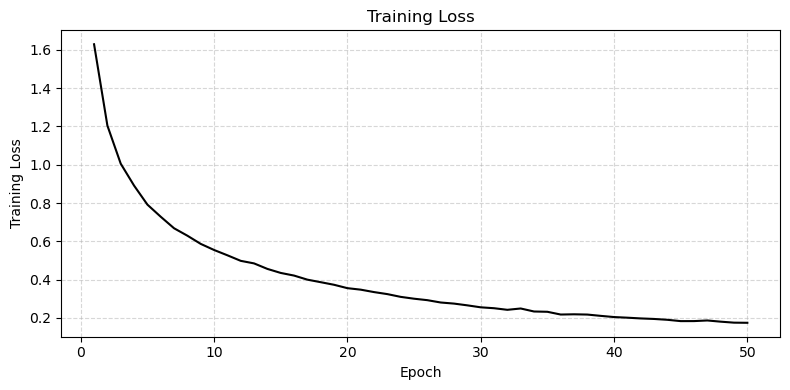

In [ ]:
# (4e) Plot the training loss as a function of epochs [3 points]

## write your code here for training and plotting [3 points]
def train_one_epoch(
    model:nn.Module,
    loader: DataLoader,
    criterion:nn.Module,
    optimiser: t.optim.Optimizer,
    device:t.device,
) -> float:
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimiser.zero_grad()
        loss = criterion(t.log(model(imgs) + 1e-9), labels)  # NLLLoss expects log-probs so I CHANGED THIS ALSO! was an error before, pls note writeup may not match am so sorry
        # please dont penalise me for mismatch thanks prof, i really need a good grade 
        loss.backward()
        optimiser.step()
        running_loss +=loss.item() * imgs.size(0)
    return running_loss/ len(loader.dataset)


train_losses: list[float] = []

for epoch in range(1, args.epochs + 1):
    loss = train_one_epoch(model, train_loader, criterion, optimiser, device)
    train_losses.append(loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}/{args.epochs}  loss: {loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, args.epochs + 1), train_losses, color="black", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()





In [65]:
# (4f) Report your test accuracy. The test accuracy should be at least 70% [4 points]

## write your code here [4 points]
def evaluate(model: nn.Module, loader: DataLoader, device: t.device) -> float:
    model.eval()
    correct = 0
    with t.no_grad():
        for imgs, labels in loader:
            imgs, labels= imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(dim=1) == labels).sum().item()
    return correct / len(loader.dataset)


test_acc = evaluate(model, test_loader, device)
print(f"Test accuracy: {test_acc * 100:.2f}%")
assert test_acc >= 0.70, "below 70% target"

class_correct= [0] * 10
class_total= [0] * 10
model.eval()
with t.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        for lbl, pred in zip(labels, preds):
            class_correct[lbl.item()] += int(pred == lbl)
            class_total[lbl.item()] += 1

print("\n Per-class accuracy:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:<12}: {class_correct[i] / class_total[i] * 100:.1f}%")

Test accuracy: 86.57%

 Per-class accuracy:
  airplane    : 80.7%
  automobile  : 94.0%
  bird        : 81.0%
  cat         : 75.3%
  deer        : 90.7%
  dog         : 73.4%
  frog        : 87.8%
  horse       : 92.5%
  ship        : 96.6%
  truck       : 93.7%
